## **23CSE301 - Machine Learning - Activity 3 - Support Vector Machines**
### **CH.SC.U4CSE24142 - SANTHOSH**
### Date : 23/08/2026

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
# Load the dataset
df = pd.read_csv('8_Support_Vector_Machine_Dataset_Exercise_2.csv')
df.head()

,crl.tot,dollar,bang,money,n000,make,yesno
0,278,0.000,0.778,0.00,0.00,0.00,y
1,1028,0.180,0.372,0.43,0.43,0.21,y
2,2259,0.184,0.276,0.06,1.16,0.06,y
3,191,0.000,0.137,0.00,0.00,0.00,y
4,191,0.000,0.135,0.00,0.00,0.00,y


In [4]:
# Check dataset information
print(df.info())

# Check for null values
print("\nNull values:\n", df.isnull().sum())

# Check class distribution
print("\nClass distribution (yes=spam, no=not spam):\n", df['yesno'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crl.tot  4601 non-null   int64  
 1   dollar   4601 non-null   float64
 2   bang     4601 non-null   float64
 3   money    4601 non-null   float64
 4   n000     4601 non-null   float64
 5   make     4601 non-null   float64
 6   yesno    4601 non-null   str    
dtypes: float64(5), int64(1), str(1)
memory usage: 256.2 KB
None

Null values:
 crl.tot    0
dollar     0
bang       0
money      0
n000       0
make       0
yesno      0
dtype: int64

Class distribution (yes=spam, no=not spam):
 yesno
n    2788
y    1813
Name: count, dtype: int64


In [5]:
# Convert categorical label 'yesno' to binary numeric values
df['label'] = df['yesno'].map({'y': 1, 'n': 0})

# Separate features and labels
X = df.drop(['yesno', 'label'], axis=1)
y = df['label']

# Split into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features (important for SVM)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [6]:
# Initialize and train SVM with a linear kernel
model_linear = SVC(kernel='linear', random_state=0)
model_linear.fit(X_train, y_train)

# Make predictions
y_pred_linear = model_linear.predict(X_test)

# Evaluate
print("Accuracy (Linear Kernel):", accuracy_score(y_test, y_pred_linear))
print("\nClassification Report:\n", classification_report(y_test, y_pred_linear))

Accuracy (Linear Kernel): 0.8305575669804489

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.95      0.87       804
           1       0.91      0.66      0.76       577

    accuracy                           0.83      1381
   macro avg       0.85      0.81      0.82      1381
weighted avg       0.84      0.83      0.82      1381



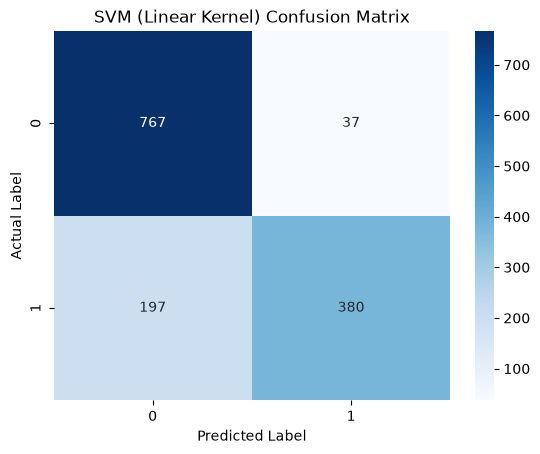

In [7]:
# Visualize the Confusion Matrix for Linear Kernel
conf_mat_linear = confusion_matrix(y_test, y_pred_linear)
sns.heatmap(conf_mat_linear, annot=True, fmt='d', cmap='Blues')
plt.title('SVM (Linear Kernel) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [8]:
# Initialize and train SVM with an RBF (Radial Basis Function) kernel
model_rbf = SVC(kernel='rbf', random_state=0)
model_rbf.fit(X_train, y_train)

# Make predictions
y_pred_rbf = model_rbf.predict(X_test)

# Evaluate
print("Accuracy (RBF Kernel):", accuracy_score(y_test, y_pred_rbf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rbf))

Accuracy (RBF Kernel): 0.8609703113685735

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.89       804
           1       0.92      0.73      0.82       577

    accuracy                           0.86      1381
   macro avg       0.88      0.84      0.85      1381
weighted avg       0.87      0.86      0.86      1381



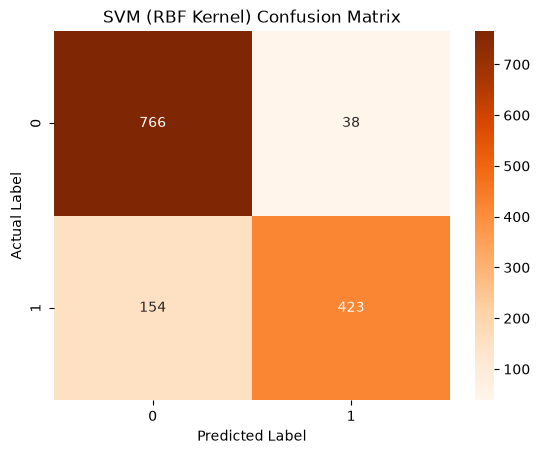

In [9]:
# Visualize the Confusion Matrix for RBF Kernel
conf_mat_rbf = confusion_matrix(y_test, y_pred_rbf)
sns.heatmap(conf_mat_rbf, annot=True, fmt='d', cmap='Oranges')
plt.title('SVM (RBF Kernel) Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()